# The wide trend sweep

This is the test the trend lane was set up to run. Take the plain trend rule, apply it to every liquid crypto USDT perp on Binance from 2020 to August 2026, and measure the money after costs and funding.

The rule. At each Sunday close, look at a coin's return over the last $L$ weeks. If it rose, go long for the next week. If it fell, go short. Sweep $L$ over 1, 2, 4, 8 and 12 weeks.

Four books apply it.

- Per coin, \$1M. Every coin trading at least \$1M a day carries its own signal.
- Per coin, \$10M. The same, on coins trading at least \$10M a day.
- Market, \$10M. One signal from the average coin's return, applied to a basket of every \$10M coin, all long or all short together.
- BTC. The rule on BTC alone.

Every position is sized by the inverse of the coin's volatility over the prior 12 weeks, so each coin carries similar risk, and the book's absolute weights sum to one.

## Setup

Load the cleaned weekly panel. Stock, ETF, commodity and tokenised real-asset perps are dropped, so the universe is crypto only. A position set at a Sunday close earns the next week's return and pays that week's funding. Cost is charged on every change of weight.

Cost is provisional. It is 7.5 bps each way on coins trading at least \$10M a day, which matches the old measured cost table, and 15 bps on smaller coins, which is a guess. Every headline is also run at zero and at twice that cost.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import panel

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, AQUA, YELLOW, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#8a8a86'

p = panel.load()
W, R, LIQ, VOL, F = p.weekly, p.simple.fillna(0.0), p.liquidity, p.vol, p.funding
COST = pd.DataFrame(np.where(LIQ >= 1e7, 7.5e-4, 15e-4), index=LIQ.index, columns=LIQ.columns)
print(f'weeks {len(W)}   {W.index[0].date()} .. {W.index[-1].date()}   coins {W.shape[1]}')

def run(w, cost_mult=1.0):
    w = w.fillna(0.0)
    turn = (w - w.shift(1).fillna(0.0)).abs()
    out = pd.DataFrame({'gross': (w * R).sum(axis=1),
                        'funding': -(w * F).sum(axis=1),
                        'cost': -(turn * COST * cost_mult).sum(axis=1),
                        'turnover': turn.sum(axis=1)})
    out['net'] = out.gross + out.funding + out.cost
    return out.loc[(w.abs().sum(axis=1) > 0).idxmax():]

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(52) if x.std() > 0 else np.nan

def sized(sig, floor):
    elig = (LIQ >= floor) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

def per_coin(L, floor):
    return sized(np.sign(W.rolling(L, min_periods=L).sum()).shift(1), floor)

def basket(floor):
    return sized(pd.DataFrame(1.0, index=W.index, columns=W.columns).where(W.shift(1).notna()), floor)

def market(L, floor):
    avg = W.where(LIQ >= floor).mean(axis=1)
    return basket(floor).mul(np.sign(avg.rolling(L, min_periods=L).sum()).shift(1), axis=0)

def btc(L):
    w = pd.DataFrame(0.0, index=W.index, columns=W.columns)
    w['BTCUSDT'] = np.sign(W['BTCUSDT'].rolling(L, min_periods=L).sum()).shift(1)
    return w

LOOKBACKS = [1, 2, 4, 8, 12]
BOOKS = {'per coin $1M': lambda L: per_coin(L, 1e6), 'per coin $10M': lambda L: per_coin(L, 1e7),
         'market $10M': lambda L: market(L, 1e7), 'BTC': btc}
weights = {(b, L): f(L) for b, f in BOOKS.items() for L in LOOKBACKS}
results = {k: run(w) for k, w in weights.items()}
long_btc = pd.DataFrame(0.0, index=W.index, columns=W.columns); long_btc['BTCUSDT'] = 1.0
references = {'long basket $10M': run(basket(1e7)), 'long BTC': run(long_btc)}

weeks 349   2020-01-05 .. 2026-09-06   coins 681


The panel is 349 weeks from January 2020 to September 2026 across 681 crypto coins, delisted ones included.

## Checking the backtest before believing it

Three checks. Random signals should lose roughly the cost of trading. A signal one week older should do worse, never better, or the backtest is seeing the future. And zero, one and two times cost should give three different answers, or cost is not wired in.

In [2]:
rng = np.random.default_rng(0)
rand = [sharpe(run(sized(pd.DataFrame(rng.choice([-1.0, 1.0], size=W.shape), index=W.index, columns=W.columns)
                         .where(W.shift(1).notna()), 1e7)).net) for _ in range(20)]
print(f'random signs, 20 runs   net Sharpe mean {np.mean(rand):+.2f}   range {min(rand):+.2f} .. {max(rand):+.2f}')
for lag in [1, 2]:
    late = sized(np.sign(W.rolling(4, min_periods=4).sum()).shift(lag), 1e7)
    print(f'per coin $10M, L=4, signal {lag} week old   net Sharpe {sharpe(run(late).net):+.2f}')
w = weights[('per coin $10M', 4)]
print('per coin $10M, L=4, at 0x 1x 2x cost', [round(sharpe(run(w, m).net), 2) for m in (0.0, 1.0, 2.0)])

random signs, 20 runs   net Sharpe mean -0.28   range -1.10 .. +0.48
per coin $10M, L=4, signal 1 week old   net Sharpe +0.85
per coin $10M, L=4, signal 2 week old   net Sharpe +0.36
per coin $10M, L=4, at 0x 1x 2x cost [np.float64(0.9), np.float64(0.85), np.float64(0.81)]


All three pass. Random signs average $-0.28$, the drag of cost and funding, and never beat $+0.48$. The real signal is outside that range. A week-old signal falls from 0.85 to 0.36. The three cost levels give three answers.

## The lookback grid

Net Sharpe for every book and lookback, with gross Sharpe, the zero and double cost versions, and where the money goes each year. Long the \$10M basket and long BTC are the reference lines.

book  per coin $1M  per coin $10M  market $10M   BTC
L                                                   
1             0.56           0.57         0.42  0.30
2             0.40           0.43         0.46  0.45
4             0.73           0.85         0.80  1.19
8             0.52           0.54         0.32  0.54
12            0.37           0.44         0.52  0.51

                   net  gross  net_0x  net_2x  return_%  cost_%  funding_%  \
book          L                                                              
per coin $1M  1   0.56   0.76    0.69    0.44     26.53   -5.97      -4.39   
              2   0.40   0.58    0.48    0.31     18.92   -4.21      -5.31   
              4   0.73   0.92    0.80    0.66     32.92   -3.14      -6.53   
              8   0.52   0.70    0.57    0.48     25.75   -2.36      -7.26   
              12  0.37   0.53    0.41    0.32     19.18   -2.24      -7.35   
per coin $10M 1   0.57   0.72    0.64    0.49     31.11   -4.32      -5.08   
    

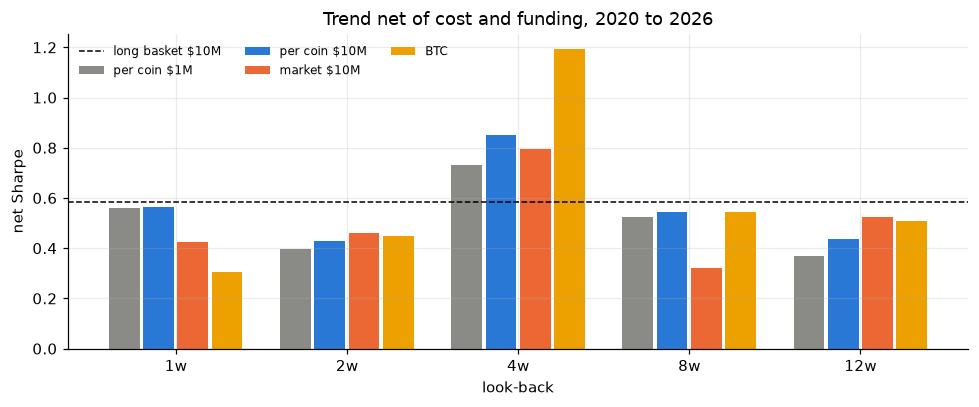

In [3]:
rows = []
for (b, L), r in results.items():
    w = weights[(b, L)]
    rows.append({'book': b, 'L': L, 'net': sharpe(r.net), 'gross': sharpe(r.gross),
                 'net_0x': sharpe(run(w, 0.0).net), 'net_2x': sharpe(run(w, 2.0).net),
                 'return_%': r.net.mean() * 5200, 'cost_%': r.cost.mean() * 5200,
                 'funding_%': r.funding.mean() * 5200, 'turnover': r.turnover.mean()})
grid = pd.DataFrame(rows)
print(grid.pivot(index='L', columns='book', values='net')[list(BOOKS)].round(2))
print()
print(grid.set_index(['book', 'L']).round(2))
print()
for k, r in references.items():
    print(f'{k:18} net Sharpe {sharpe(r.net):+.2f}   return {r.net.mean() * 5200:+.1f}% a year')

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(LOOKBACKS)); wd = 0.2
piv = grid.pivot(index='L', columns='book', values='net')
for i, (b, colour) in enumerate(zip(BOOKS, [GREY, BLUE, ORANGE, YELLOW])):
    ax.bar(x + (i - 1.5) * wd, piv[b], width=wd - 0.02, color=colour, label=b)
ax.axhline(sharpe(references['long basket $10M'].net), color='k', ls='--', lw=1, label='long basket $10M')
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([f'{L}w' for L in LOOKBACKS]); ax.set_xlabel('look-back')
ax.set_ylabel('net Sharpe'); ax.set_title('Trend net of cost and funding, 2020 to 2026')
ax.legend(frameon=False, ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

Every book is positive at every lookback, from 0.30 to 1.19 net. Four weeks is the best lookback in every book. Per coin \$10M makes 0.85, the market book 0.80 and BTC 1.19, against 0.58 for simply holding the basket and 0.64 for holding BTC.

The old sawtooth is gone. On ten coins, 1 and 4 weeks won and 2 and 8 lost. Across the wide universe every lookback earns, with a single peak at 4 weeks.

Cost is not the constraint at these turnovers. Doubling it moves the 4-week per coin \$10M book from 0.85 to 0.81. Funding is the bigger drag, 6.5% a year on the per coin book and 12% on the market book, which spends more time long in hot funding.

The \$1M book trails the \$10M one at every lookback. It holds the same liquid coins plus the smaller ones, so the smaller ones pull it down.

## Year by year

The same books split by calendar year, at lookbacks 1, 4 and 12 weeks.

In [4]:
yearly = {}
for b in BOOKS:
    for L in [1, 4, 12]:
        r = results[(b, L)].net
        yearly[f'{b} L={L}'] = r.groupby(r.index.year).apply(sharpe)
for k, r in references.items():
    yearly[k] = r.net.groupby(r.net.index.year).apply(sharpe)
print(pd.DataFrame(yearly).T.round(2))

day                 2020  2021  2022  2023  2024  2025  2026
per coin $1M L=1    0.76  1.15  0.58  0.41  0.60  0.32 -1.50
per coin $1M L=4    1.03  1.64  0.71  0.17 -0.44  1.66 -0.73
per coin $1M L=12   0.32  1.19  0.54 -0.76 -0.31  0.69 -0.22
per coin $10M L=1   0.53  1.11  0.71  0.64  0.71  0.18 -0.92
per coin $10M L=4   1.06  1.69  0.79  0.82  0.25  1.15 -0.64
per coin $10M L=12  0.32  1.23  0.57 -0.32  0.52  0.01 -0.26
market $10M L=1    -0.16  1.00 -0.46  0.97  1.24  0.15 -0.80
market $10M L=4    -0.63  1.73  0.76  1.06  0.44  1.27 -0.53
market $10M L=12   -0.47  1.16  0.97 -0.03  0.90 -0.07  0.08
BTC L=1             0.69  0.83  0.13 -0.03 -0.00  0.25 -0.20
BTC L=4             2.28  1.76  1.06  1.76  0.43  0.55 -0.33
BTC L=12            2.58  0.66  0.63 -0.27  0.53  0.53 -1.05
long basket $10M    2.37  2.10 -1.63  1.38  0.74 -0.85 -0.11
long BTC            1.70  0.85 -1.77  1.88  1.59 -0.12 -0.17


The 4-week per coin \$10M book is positive in every full year from 2020 to 2025, from 0.25 in 2024 to 1.69 in 2021, and positive in the 2022 bear at 0.79 while holding the basket lost $-1.63$.

2026 breaks it. Every trend book is negative in 2026 so far, the year the EDA found correlation between coins collapsing. The market book also lost in 2020.

BTC alone looks best on the full sample but leans on 2020 and 2021, at 2.28 and 1.76, and is weak from 2024.

## Small coins against liquid coins

The \$1M book is the \$10M coins plus every coin trading \$1M to \$10M a day. To see what the smaller coins contribute on their own, run the per coin rule on three sets. Small coins only, liquid coins only, and both together. Report each set's share of the combined book's weight, its years at 4 weeks, and how closely the small and liquid books move together.

In [5]:
def band(L, lo, hi):
    sig = np.sign(W.rolling(L, min_periods=L).sum()).shift(1)
    elig = (LIQ >= lo) & (LIQ < hi) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

rows = []
for L in LOOKBACKS:
    small, liquid, both = run(band(L, 1e6, 1e7)), run(band(L, 1e7, np.inf)), run(band(L, 1e6, np.inf))
    wb = band(L, 1e6, np.inf).fillna(0.0)
    rows.append({'L': L, 'small only': sharpe(small.net), 'small gross': sharpe(small.gross),
                 'liquid only': sharpe(liquid.net), 'both': sharpe(both.net),
                 'small share of weight': wb.abs().where(LIQ < 1e7).sum(axis=1).mean()})
print('net Sharpe')
print(pd.DataFrame(rows).set_index('L').round(2))
print()
small4, liquid4 = run(band(4, 1e6, 1e7)).net, run(band(4, 1e7, np.inf)).net
print('L = 4, by year')
print(pd.DataFrame({'small only': small4.groupby(small4.index.year).apply(sharpe),
                    'liquid only': liquid4.groupby(liquid4.index.year).apply(sharpe)}).T.round(2))
print(f'correlation of small and liquid books at L = 4   {small4.corr(liquid4):.2f}')

net Sharpe
    small only  small gross  liquid only  both  small share of weight
L                                                                    
1         0.42         0.67         0.57  0.56                   0.38
2         0.52         0.71         0.43  0.40                   0.38
4         0.46         0.64         0.85  0.73                   0.38
8         0.24         0.41         0.54  0.52                   0.38
12        0.26         0.42         0.44  0.37                   0.36

L = 4, by year
day          2020  2021  2022  2023  2024  2025  2026
small only   2.08  1.43 -0.23 -0.23 -1.88  1.45 -0.77
liquid only  1.06  1.69  0.79  0.82  0.25  1.15 -0.64
correlation of small and liquid books at L = 4   0.61


Small coins earn on their own, from 0.24 to 0.52 net and 0.64 gross at 4 weeks. At 2 weeks they edge the liquid coins, 0.52 against 0.43. At every other lookback they trail, and at 4 weeks they make 0.46 against 0.85.

They are far less reliable. At 4 weeks the small book lost in 2022, 2023 and 2024, down to $-1.88$ in 2024, while the liquid book was positive every full year to 2025.

Most of what they earn is the same market bet. The two books correlate 0.61.

They take about 38% of the combined book's weight, which is why mixing them in lands between the two, at 0.73. Their cost of 15 bps each way is a guess, so their true number is likely lower. Small coins carry a weaker, less reliable version of the same trend.

## Walk-forward

Picking the best lookback after seeing the whole sample flatters it. Split the weeks into five equal blocks, pick the lookback with the best net Sharpe on the first three, and report it on the last two, which the choice never saw.

In [6]:
wf = []
for b in BOOKS:
    nets = {L: results[(b, L)].net for L in LOOKBACKS}
    idx = nets[1].index
    blocks = np.array_split(np.arange(len(idx)), 5)
    train, test = idx[np.concatenate(blocks[:3])], idx[np.concatenate(blocks[3:])]
    tr = {L: sharpe(nets[L].reindex(train)) for L in LOOKBACKS}
    te = {L: sharpe(nets[L].reindex(test)) for L in LOOKBACKS}
    best = max(tr, key=tr.get)
    wf.append({'book': b, 'train': f'{train[0].date()} .. {train[-1].date()}', 'test': f'{test[0].date()} .. {test[-1].date()}',
               'picked L': best, 'train Sharpe': tr[best], 'test Sharpe': te[best], **{f'test L={L}': te[L] for L in LOOKBACKS}})
print(pd.DataFrame(wf).set_index('book').round(2).T)

book                      per coin $1M             per coin $10M  \
train         2020-04-05 .. 2024-02-11  2020-04-05 .. 2024-02-11   
test          2024-02-18 .. 2026-09-06  2024-02-18 .. 2026-09-06   
picked L                             4                         4   
train Sharpe                      0.91                      1.04   
test Sharpe                       0.35                      0.55   
test L=1                          0.16                      0.26   
test L=2                           0.1                      0.25   
test L=4                          0.35                      0.55   
test L=8                          0.18                      0.23   
test L=12                         0.11                      0.22   

book                       market $10M                       BTC  
train         2020-04-05 .. 2024-02-11  2020-02-16 .. 2024-01-28  
test          2024-02-18 .. 2026-09-06  2024-02-04 .. 2026-09-06  
picked L                             4            

Four weeks is picked in every book. On the unseen stretch from February 2024 to September 2026, the market book makes 0.67, per coin \$10M 0.55, per coin \$1M 0.35 and BTC 0.29.

Every lookback of the two \$10M books stays positive out of sample. That breadth matters more than the winner.

## Correcting for how many things were tried

Try enough strategies and one will look good by luck. The deflated Sharpe asks how likely a result is to be real, given how many trials were run and how fat the tails of its returns are. The count is 45. That is the 20 cells here plus about 25 earlier trials on the ten-coin sample, which tested the same hypotheses and so still count.

In [7]:
def deflated(x, trials, all_sharpes):
    x = x.dropna(); T = len(x); sr = x.mean() / x.std()
    g = 0.5772156649
    bar = np.std(all_sharpes) * ((1 - g) * stats.norm.ppf(1 - 1 / trials) + g * stats.norm.ppf(1 - 1 / (trials * np.e)))
    sk, ku = stats.skew(x), stats.kurtosis(x, fisher=False)
    prob = stats.norm.cdf((sr - bar) * np.sqrt(T - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2))
    return sr * np.sqrt(52), bar * np.sqrt(52), prob

all_sr = [r.net.mean() / r.net.std() for r in results.values()]
for b in ['per coin $10M', 'market $10M', 'BTC']:
    sr, bar, prob = deflated(results[(b, 4)].net, 45, all_sr)
    print(f'{b:14} L=4   Sharpe {sr:.2f}   luck bar for 45 trials {bar:.2f}   probability real {prob:.2f}')

per coin $10M  L=4   Sharpe 0.85   luck bar for 45 trials 0.46   probability real 0.84
market $10M    L=4   Sharpe 0.80   luck bar for 45 trials 0.46   probability real 0.81
BTC            L=4   Sharpe 1.19   luck bar for 45 trials 0.46   probability real 0.97


The luck bar for 45 trials is a Sharpe of 0.46. Per coin \$10M clears it with an 84% probability of being real, the market book 81%, BTC 97%. Real enough to pursue, not certain.

## How much of it is a market bet

When most coins rise together, the per coin book ends up long almost everything, which is just a bet on the market. Split its profit exactly into two parts. The market part is its net long or short exposure times the basket. The rest nets to zero, and earns only from picking which coins to be long and short.

Then test the rest twice. Remove its hidden exposure to how strongly coins follow the market, called beta. And cap every weekly move at 2 standard deviations, to see whether a few huge moves carry it.

In [8]:
b10 = basket(1e7).fillna(0.0)
mk = np.log1p((b10 * R).sum(axis=1))
beta = pd.DataFrame({c: W[c].rolling(26, min_periods=13).cov(mk) for c in W.columns}).div(mk.rolling(26, min_periods=13).var(), axis=0).shift(1)
z = W / VOL
R_capped = np.expm1((z.clip(-2, 2) * VOL).where(W.notna(), np.log1p(R)))

rows = []
for L in LOOKBACKS:
    w = weights[('per coin $10M', L)].fillna(0.0)
    mkt_part = b10.mul(w.sum(axis=1), axis=0)
    rest = w - mkt_part
    beta_neutral = rest - b10.mul((rest * beta).sum(axis=1), axis=0)
    full, m, r = run(w, 0.0).gross, run(mkt_part, 0.0).gross, run(rest, 0.0).gross
    capped = ((rest * R_capped).sum(axis=1)).loc[r.index]
    rows.append({'L': L, 'full': sharpe(full), 'market part': sharpe(m), 'rest': sharpe(r),
                 'rest share of profit': r.sum() / full.sum(), 'rest, beta removed': sharpe(run(beta_neutral, 0.0).gross),
                 'rest, moves capped': sharpe(capped),
                 'corr with market book': results[('per coin $10M', L)].net.corr(results[('market $10M', L)].net)})
print('gross Sharpe, per coin $10M book')
print(pd.DataFrame(rows).set_index('L').round(2))
print()
wt = W.where(LIQ >= 1e7); avg = wt.mean(axis=1); rel = wt.sub(avg, axis=0); rv = rel.rolling(12, min_periods=8).std().shift(1)
for L in [1, 2, 4]:
    past = rel.rolling(L, min_periods=L).sum() / (rv * np.sqrt(L)); nxt = (rel / rv).shift(-1)
    ic = past.corrwith(nxt, axis=1, method='spearman')[(past.notna() & nxt.notna()).sum(axis=1) >= 20].dropna()
    print(f'coin vs market rank correlation, $10M coins, L={L}   {ic.mean():+.3f}   t {ic.mean() / ic.std() * np.sqrt(len(ic)):+.1f}')

gross Sharpe, per coin $10M book
    full  market part  rest  rest share of profit  rest, beta removed  \
L                                                                       
1   0.72         0.56  0.88                  0.25                0.93   
2   0.58         0.35  1.08                  0.42                1.18   
4   0.99         0.82  0.93                  0.20                0.82   
8   0.68         0.63  0.40                  0.10                0.53   
12  0.57         0.53  0.36                  0.10                0.14   

    rest, moves capped  corr with market book  
L                                              
1                 0.55                   0.85  
2                 0.82                   0.87  
4                 0.75                   0.80  
8                 0.36                   0.85  
12                0.35                   0.92  

coin vs market rank correlation, $10M coins, L=1   -0.021   t -1.9


coin vs market rank correlation, $10M coins, L=2   -0.025   t -2.1
coin vs market rank correlation, $10M coins, L=4   -0.002   t -0.2


The per coin book is mostly a market bet. At 4 weeks the market part carries 80% of its profit, and its returns correlate 0.80 with the market book.

The rest still earns, 0.93 gross at 4 weeks. It survives removing beta, 0.82, and capping every move at 2 standard deviations, 0.75. So long the coins that rose and short the coins that fell earns something beyond the market among liquid coins.

That clashes with the rank view. Ranked week by week, liquid coins still snap back slightly against the market, $-0.021$ at 1 week and 1.9 standard errors from zero. Ranks and money disagree, and this notebook does not resolve why. The rest is an open lead, not a finding.

## Against the bar

The bar was written before any run. Out of sample net Sharpe above 0.7, positive in every calendar year, still positive at twice cost, cost plus funding under 40% of gross profit, and positive in the bear year. Check the two \$10M books at 4 weeks.

In [9]:
gate = {}
for b in ['per coin $10M', 'market $10M']:
    r, w = results[(b, 4)], weights[(b, 4)]
    yrs = r.net.groupby(r.net.index.year).sum()
    oos = next(x for x in wf if x['book'] == b)['test Sharpe']
    gate[b] = {'out of sample Sharpe > 0.7': f'{oos:.2f}',
               'positive every year': f'{(yrs > 0).sum()} of {len(yrs)}, losing {[y for y in yrs.index if yrs[y] <= 0]}',
               'positive at 2x cost': f'{sharpe(run(w, 2.0).net):.2f}',
               'cost + funding under 40% of gross': f'{-(r.cost.sum() + r.funding.sum()) / r.gross.sum():.0%}',
               '2022 bear positive': f'{sharpe(r.net.loc["2022"]):.2f}'}
print(pd.DataFrame(gate))

                                           per coin $10M  \
out of sample Sharpe > 0.7                          0.55   
positive every year                6 of 7, losing [2026]   
positive at 2x cost                                 0.81   
cost + funding under 40% of gross                    16%   
2022 bear positive                                  0.79   

                                                   market $10M  
out of sample Sharpe > 0.7                                0.67  
positive every year                5 of 7, losing [2020, 2026]  
positive at 2x cost                                       0.77  
cost + funding under 40% of gross                          19%  
2022 bear positive                                        0.76  


Neither book passes in full, and both miss out of sample Sharpe.

The market book makes 0.67 out of sample against the bar of 0.7. It clears twice cost and the bear year, with drag at 19% of gross, and fails positive every year, losing 2020 and 2026.

The per coin \$10M book makes 0.55 out of sample. It clears twice cost, drag at 16% and the bear year, and fails positive every year on 2026 alone.

Both fail on the year coins stopped moving together, and cost here is provisional.

## Verdict

The lane does not close. Trend on liquid crypto perps earns across every lookback and every full year to 2025, with 4 weeks best, a net Sharpe of 0.80 to 0.85 over the whole span and 0.55 to 0.67 out of sample. It is mostly a bet on the market's own trend.

It does not pass the pooled bar. 2026 is negative for every trend book, and neither book reaches 0.7 out of sample. Costs are provisional until they are measured.